Style configured. Saving all figures to: C:\Users\miy\Downloads\1000_논문투고\68.독거노인 돌봄용 위험감지 데이터\3.개방데이터\causal_fusion_paper\figures
All results loaded.


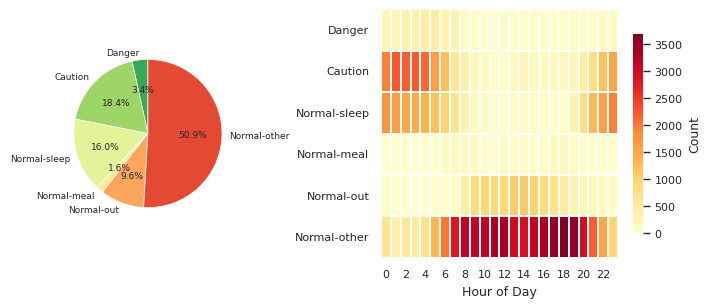

Saved fig1_label_dist


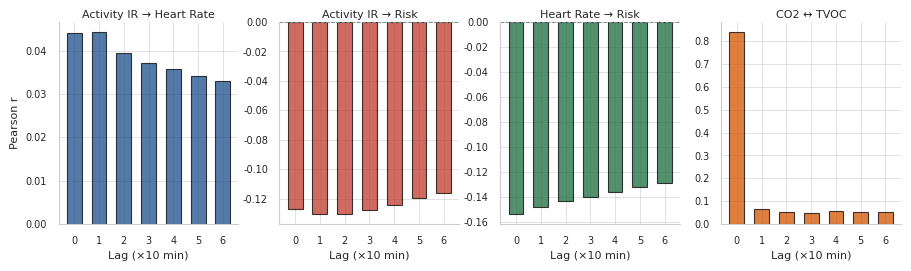

Saved fig2_lag_ccf


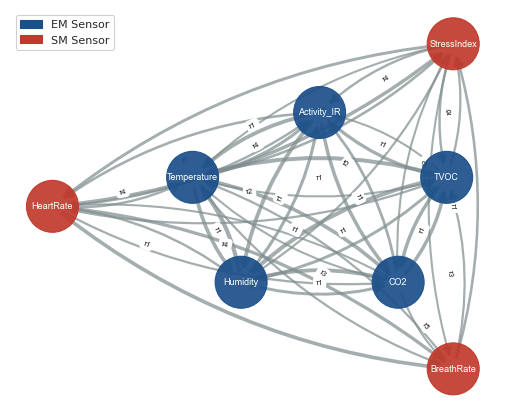

Saved fig3_causal_dag


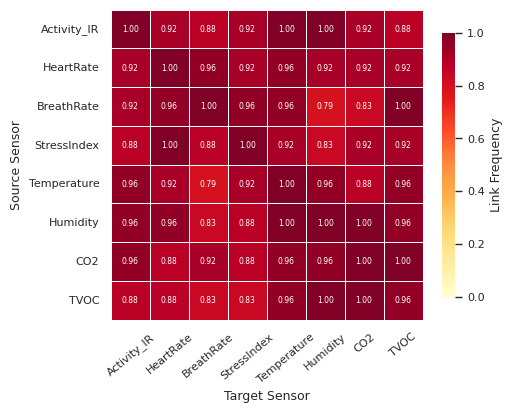

Saved fig4_causal_freq_heatmap


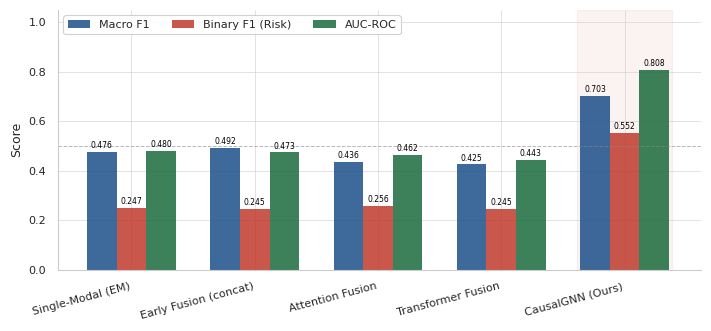

Saved fig5_model_comparison


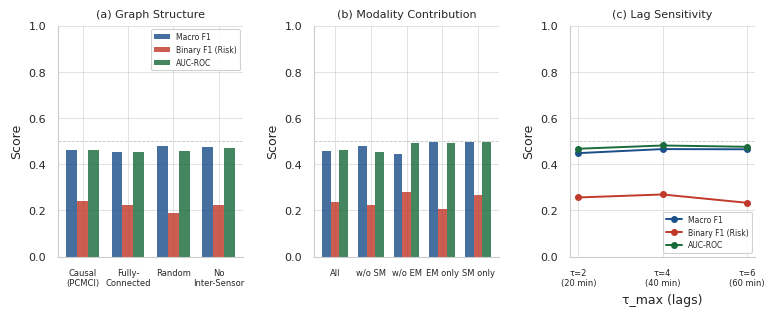

Saved fig6_ablation


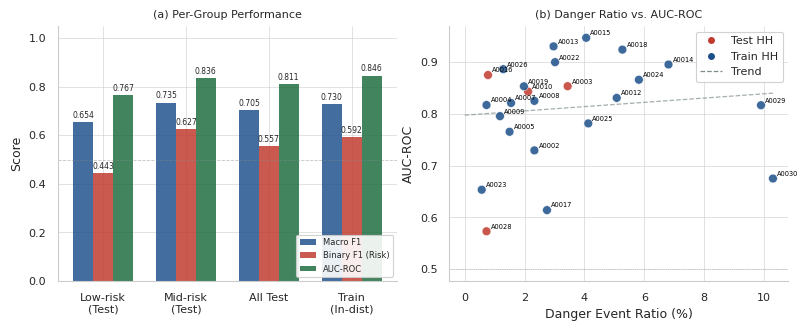

Saved fig7_generalization


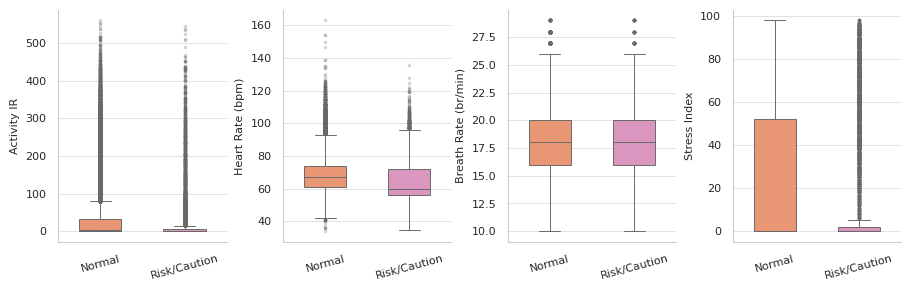

Saved fig8_sensor_boxplot

All figures saved  (PDF + PNG, {DPI} DPI)
  fig1_label_dist.pdf
  fig2_lag_ccf.pdf
  fig3_causal_dag.pdf
  fig4_causal_freq_heatmap.pdf
  fig5_model_comparison.pdf
  fig6_ablation.pdf
  fig7_generalization.pdf
  fig8_sensor_boxplot.pdf


In [1]:
# ============================================================
# Notebook : 07_figures.ipynb
# Path     : causal_fusion_paper/07_figures.ipynb
# Purpose  : Publication-quality figures for Pattern Recognition
#            All figures: 600 DPI, no captions, seaborn-based
# Author   : [Your Name]
# Created  : 2026-06-11
# ============================================================


# ── Cell 0. Style Setup ──────────────────────────────────────
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
import networkx as nx

warnings.filterwarnings('ignore')

ROOT    = Path().resolve()
FIG_DIR = ROOT / "figures"
RES_DIR = ROOT / "results"
CACHE   = ROOT / "data_cache"

DPI      = 600
FONT_SZ  = 8       # axis tick / legend
LABEL_SZ = 9       # axis label
TITLE_SZ = 10      # subplot title (unused in final — no captions)

# Seaborn base style
matplotlib.rcParams['font.family']       = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', context='paper',
              rc={
                  'font.family':        'DejaVu Sans',
                  'axes.unicode_minus': False,
                  'font.size':          FONT_SZ,
                  'axes.labelsize':     LABEL_SZ,
                  'xtick.labelsize':    FONT_SZ,
                  'ytick.labelsize':    FONT_SZ,
                  'legend.fontsize':    FONT_SZ,
                  'axes.linewidth':     0.8,
                  'grid.linewidth':     0.4,
                  'lines.linewidth':    1.2,
              })

# Colour palette (colour-blind friendly)
PAL_6    = sns.color_palette('Set2', 6)
PAL_RISK = {'Normal': PAL_6[1], 'Risk/Caution': PAL_6[3]}
BLUE     = '#1B4F8A'
RED      = '#C0392B'
GREEN    = '#1A6B3C'
ORANGE   = '#D35400'
GRAY     = '#7F8C8D'

FEAT_COLS = ['Activity_IR', 'HeartRate', 'BreathRate', 'StressIndex',
             'Temperature', 'Humidity', 'CO2', 'TVOC']

print("Style configured. Saving all figures to:", FIG_DIR)


# ── Cell 1. Load All Results ─────────────────────────────────
df       = pd.read_pickle(CACHE / "df_new.pkl")

LABEL_MAP = {'위험':'Danger','주의':'Caution','수면':'Normal-sleep',
             '식사':'Normal-meal','외출':'Normal-out','기타':'Normal-other'}
df['Estimation_EN'] = df['Estimation'].map(LABEL_MAP)
df['Hour']          = pd.to_datetime(df['Timestamp']).dt.hour
df['Risk_bin']      = df['Estimation'].isin(['위험','주의']).astype(float)
df.loc[df['Estimation'].isna(), 'Risk_bin'] = np.nan

df_links  = pd.read_csv(RES_DIR / "causal_links_all.csv")
df_stable = pd.read_csv(RES_DIR / "stable_causal_links.csv")
df_all    = pd.read_csv(RES_DIR / "metrics_all_models.csv")
df_ablA   = pd.read_csv(RES_DIR / "ablation_A_graph_structure.csv")
df_ablB   = pd.read_csv(RES_DIR / "ablation_B_modality.csv")
df_ablC   = pd.read_csv(RES_DIR / "ablation_C_lag.csv")
df_gen    = pd.read_csv(RES_DIR / "generalization_results.csv")
df_hh     = pd.read_csv(RES_DIR / "per_household_performance.csv")
ADJ       = np.load(RES_DIR / "causal_adj.npy")[:8, :8, :]

print("All results loaded.")


# ── Cell 2. Fig 1 — Label Distribution & Risk Hour Heatmap ──
LABEL_ORDER = ['Danger','Caution','Normal-sleep',
               'Normal-meal','Normal-out','Normal-other']
PAL_LABEL   = dict(zip(LABEL_ORDER,
                       sns.color_palette('RdYlGn_r', len(LABEL_ORDER))))

fig, axes = plt.subplots(1, 2, figsize=(7, 3),
                         gridspec_kw={'width_ratios': [1, 1.6]})

# (a) Pie — label distribution
counts = (df['Estimation_EN']
          .value_counts()
          .reindex(LABEL_ORDER, fill_value=0))
wedge_props = dict(linewidth=0.5, edgecolor='white')
axes[0].pie(counts,
            labels=LABEL_ORDER,
            colors=[PAL_LABEL[l] for l in LABEL_ORDER],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops=wedge_props,
            textprops={'fontsize': 6.5})
axes[0].set_aspect('equal')

# (b) Heatmap — hour × label
dn = df[df['Estimation_EN'].notna()].copy()
pivot = (dn.groupby(['Hour','Estimation_EN'])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=[c for c in LABEL_ORDER
                              if c in dn['Estimation_EN'].unique()]))
sns.heatmap(pivot.T, ax=axes[1],
            cmap='YlOrRd', linewidths=0.3, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Count'},
            xticklabels=2)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout(pad=0.5)
plt.savefig(FIG_DIR / 'fig1_label_dist.pdf',
            dpi=DPI, bbox_inches='tight', format='pdf')
plt.savefig(FIG_DIR / 'fig1_label_dist.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved fig1_label_dist")


# ── Cell 3. Fig 2 — Lag Cross-Correlation ───────────────────
from scipy import stats

def cross_corr(x, y, max_lag=6):
    out = {}
    for lag in range(max_lag + 1):
        xi = x.iloc[:len(x)-lag].values
        yi = y.iloc[lag:].values
        mask = ~(np.isnan(xi) | np.isnan(yi))
        out[lag] = stats.pearsonr(xi[mask], yi[mask]) if mask.sum() > 10 \
                   else (np.nan, np.nan)
    return out

PAIRS = [
    ('Activity_IR', 'HeartRate',  'Activity IR → Heart Rate'),
    ('Activity_IR', 'Risk_bin',   'Activity IR → Risk'),
    ('HeartRate',   'Risk_bin',   'Heart Rate → Risk'),
    ('CO2',         'TVOC',       'CO2 ↔ TVOC'),
]
CLRS_PAIRS = [BLUE, RED, GREEN, ORANGE]

fig, axes = plt.subplots(1, 4, figsize=(9, 2.6), sharey=False)
for ax, (cx, cy, lbl), clr in zip(axes, PAIRS, CLRS_PAIRS):
    res  = cross_corr(df[cx], df[cy])
    lags = list(res.keys())
    rs   = [res[l][0] for l in lags]
    ps   = [res[l][1] for l in lags]
    bars = ax.bar(lags, rs, color=clr, alpha=0.75, width=0.6,
                  edgecolor='none')
    for bar, p in zip(bars, ps):
        if p is not None and not np.isnan(p) and p < 0.05:
            bar.set_edgecolor('black')
            bar.set_linewidth(0.8)
    ax.axhline(0, color=GRAY, lw=0.7, ls='--')
    ax.set_xlabel('Lag (×10 min)', fontsize=FONT_SZ)
    ax.set_ylabel('Pearson r' if ax == axes[0] else '', fontsize=FONT_SZ)
    ax.set_title(lbl, fontsize=FONT_SZ, pad=3)
    ax.set_xticks(lags)
    ax.tick_params(labelsize=FONT_SZ - 1)
    sns.despine(ax=ax)

plt.tight_layout(pad=0.4)
plt.savefig(FIG_DIR / 'fig2_lag_ccf.pdf',
            dpi=DPI, bbox_inches='tight', format='pdf')
plt.savefig(FIG_DIR / 'fig2_lag_ccf.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved fig2_lag_ccf")


# ── Cell 4. Fig 3 — Aggregate Causal DAG ────────────────────
MODALITY = {
    'Activity_IR': 'EM', 'Temperature': 'EM', 'Humidity': 'EM',
    'CO2':         'EM', 'TVOC':        'EM',
    'HeartRate':   'SM', 'BreathRate':  'SM', 'StressIndex': 'SM',
}
MOD_COLOR = {'EM': BLUE, 'SM': RED}
NODE_COLOR = [MOD_COLOR[MODALITY[n]] for n in FEAT_COLS]

# Build graph from stable links (exclude self-loops for clarity)
G   = nx.DiGraph()
G.add_nodes_from(FEAT_COLS)
idx_map = {c: i for i, c in enumerate(FEAT_COLS)}

# Best lag per pair (highest freq)
best = (df_stable.sort_values('freq', ascending=False)
                 .drop_duplicates(['Source','Target'])
                 .query("Source != Target"))   # remove self-loops
for _, row in best.iterrows():
    if row['Source'] in idx_map and row['Target'] in idx_map:
        G.add_edge(row['Source'], row['Target'],
                   freq=row['freq'], lag=int(row['Lag']))

pos = nx.shell_layout(G, nlist=[
    [n for n in FEAT_COLS if MODALITY[n] == 'EM'],
    [n for n in FEAT_COLS if MODALITY[n] == 'SM'],
])

fig, ax = plt.subplots(figsize=(5, 4))
ax.set_facecolor('white')

edge_widths = [G[u][v]['freq'] * 3 for u,v in G.edges()]
edge_alphas = [max(0.3, G[u][v]['freq']) for u,v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_color=NODE_COLOR,
                       node_size=1400, alpha=0.92, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=6.5,
                        font_color='white', ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths,
                       edge_color=GRAY, alpha=0.7,
                       arrows=True, arrowsize=14,
                       connectionstyle='arc3,rad=0.15', ax=ax)
edge_lbl = {(u,v): f"τ{G[u][v]['lag']}" for u,v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_lbl,
                             font_size=5.5, ax=ax)

legend_handles = [
    mpatches.Patch(color=BLUE, label='EM Sensor'),
    mpatches.Patch(color=RED,  label='SM Sensor'),
]
ax.legend(handles=legend_handles, loc='upper left',
          fontsize=FONT_SZ, framealpha=0.9)
ax.axis('off')

plt.tight_layout(pad=0.3)
plt.savefig(FIG_DIR / 'fig3_causal_dag.pdf',
            dpi=DPI, bbox_inches='tight', format='pdf')
plt.savefig(FIG_DIR / 'fig3_causal_dag.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved fig3_causal_dag")


# ── Cell 5. Fig 4 — Causal Link Frequency Heatmap ───────────
n_usable = df_links['HH_ID'].nunique()
freq_all  = (df_links.groupby(['Source','Target'])
                     .agg(n_hh=('HH_ID','nunique'))
                     .reset_index()
                     .assign(freq=lambda x: x['n_hh'] / n_usable))
pivot_freq = (freq_all.pivot(index='Source', columns='Target', values='freq')
                      .reindex(index=FEAT_COLS, columns=FEAT_COLS, fill_value=0))

fig, ax = plt.subplots(figsize=(5, 4))
mask = pivot_freq == 0
sns.heatmap(pivot_freq, ax=ax,
            cmap='YlOrRd', vmin=0, vmax=1,
            mask=mask,
            linewidths=0.4, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 5.5},
            cbar_kws={'shrink': 0.85, 'label': 'Link Frequency'})
ax.set_xlabel('Target Sensor', fontsize=LABEL_SZ)
ax.set_ylabel('Source Sensor', fontsize=LABEL_SZ)
ax.tick_params(axis='x', rotation=40, labelsize=FONT_SZ)
ax.tick_params(axis='y', rotation=0,  labelsize=FONT_SZ)

plt.tight_layout(pad=0.3)
plt.savefig(FIG_DIR / 'fig4_causal_freq_heatmap.pdf',
            dpi=DPI, bbox_inches='tight', format='pdf')
plt.savefig(FIG_DIR / 'fig4_causal_freq_heatmap.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved fig4_causal_freq_heatmap")


# ── Cell 6. Fig 5 — Model Comparison Bar Chart ──────────────
MODEL_ORDER = ['Single-Modal (EM)', 'Early Fusion (concat)',
               'Attention Fusion', 'Transformer Fusion',
               'CausalGNN (Ours)']
METRICS     = ['Macro_F1', 'Binary_F1', 'AUC_ROC']
MET_LABELS  = ['Macro F1', 'Binary F1 (Risk)', 'AUC-ROC']

df_plot = df_all.set_index('Model').reindex(MODEL_ORDER).reset_index()
x       = np.arange(len(MODEL_ORDER))
w       = 0.24
clrs    = [BLUE, RED, GREEN]

fig, ax = plt.subplots(figsize=(7, 3.2))
for k, (col, lbl, clr) in enumerate(zip(METRICS, MET_LABELS, clrs)):
    vals  = df_plot[col].values
    rects = ax.bar(x + k*w, vals, w, label=lbl,
                   color=clr, alpha=0.85, edgecolor='none')
    for rect, v in zip(rects, vals):
        ax.text(rect.get_x() + rect.get_width()/2,
                rect.get_height() + 0.008,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=5.5, color='black')

ax.axhline(0.5, color=GRAY, lw=0.7, ls='--', alpha=0.6)
ax.set_xticks(x + w)
ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right',
                   fontsize=FONT_SZ)
ax.set_ylabel('Score', fontsize=LABEL_SZ)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=FONT_SZ, loc='upper left',
          framealpha=0.9, ncol=3)
# Highlight CausalGNN column
ax.axvspan(x[-1] - w*0.6, x[-1] + w*2.6,
           alpha=0.06, color=RED, zorder=0)
sns.despine(ax=ax)

plt.tight_layout(pad=0.4)
plt.savefig(FIG_DIR / 'fig5_model_comparison.pdf',
            dpi=DPI, bbox_inches='tight', format='pdf')
plt.savefig(FIG_DIR / 'fig5_model_comparison.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved fig5_model_comparison")


# ── Cell 7. Fig 6 — Ablation Study (3 panels) ───────────────
fig = plt.figure(figsize=(9, 3))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# (a) Graph structure
ax  = fig.add_subplot(gs[0])
x   = np.arange(len(df_ablA))
w   = 0.24
for k, (col, lbl, clr) in enumerate(zip(METRICS, MET_LABELS, clrs)):
    ax.bar(x + k*w, df_ablA[col], w, label=lbl,
           color=clr, alpha=0.82, edgecolor='none')
ax.set_xticks(x + w)
ax.set_xticklabels(
    ['Causal\n(PCMCI)', 'Fully-\nConnected',
     'Random', 'No\nInter-Sensor'],
    fontsize=6)
ax.set_ylabel('Score', fontsize=LABEL_SZ)
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color=GRAY, lw=0.6, ls='--', alpha=0.5)
ax.set_title('(a) Graph Structure', fontsize=FONT_SZ)
ax.legend(fontsize=5.5, loc='upper right', framealpha=0.9)
sns.despine(ax=ax)

# (b) Modality
ax  = fig.add_subplot(gs[1])
x   = np.arange(len(df_ablB))
for k, (col, lbl, clr) in enumerate(zip(METRICS, MET_LABELS, clrs)):
    ax.bar(x + k*w, df_ablB[col], w, label=lbl,
           color=clr, alpha=0.82, edgecolor='none')
ax.set_xticks(x + w)
ax.set_xticklabels(
    ['All', 'w/o SM', 'w/o EM', 'EM only', 'SM only'],
    fontsize=6)
ax.set_ylabel('Score', fontsize=LABEL_SZ)
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color=GRAY, lw=0.6, ls='--', alpha=0.5)
ax.set_title('(b) Modality Contribution', fontsize=FONT_SZ)
sns.despine(ax=ax)

# (c) Lag sensitivity
ax = fig.add_subplot(gs[2])
for col, lbl, clr in zip(METRICS, MET_LABELS, clrs):
    ax.plot(df_ablC['tau_max'], df_ablC[col], 'o-',
            label=lbl, color=clr, lw=1.4, ms=4)
ax.set_xlabel('τ_max (lags)', fontsize=LABEL_SZ)
ax.set_ylabel('Score', fontsize=LABEL_SZ)
ax.set_xticks(df_ablC['tau_max'])
ax.set_xticklabels([f'τ={t}\n({t*10} min)'
                    for t in df_ablC['tau_max']], fontsize=6)
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color=GRAY, lw=0.6, ls='--', alpha=0.5)
ax.set_title('(c) Lag Sensitivity', fontsize=FONT_SZ)
ax.legend(fontsize=5.5, loc='lower right', framealpha=0.9)
sns.despine(ax=ax)

plt.savefig(FIG_DIR / 'fig6_ablation.pdf',
            dpi=DPI, bbox_inches='tight', format='pdf')
plt.savefig(FIG_DIR / 'fig6_ablation.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved fig6_ablation")


# ── Cell 8. Fig 7 — Generalization Analysis ─────────────────
df_hh2 = df_hh[df_hh['AUC_ROC'].notna() &
                (df_hh['danger_ratio'] > 0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))

# (a) Group bar chart
grp_plot = df_gen[df_gen['Group'].str.contains('G[234]|G5', regex=True)].copy()
grp_plot = grp_plot[~grp_plot['Group'].str.contains('G1')]
x  = np.arange(len(grp_plot))
for k, (col, lbl, clr) in enumerate(zip(METRICS, MET_LABELS, clrs)):
    rects = axes[0].bar(x + k*w, grp_plot[col], w,
                        label=lbl, color=clr, alpha=0.83,
                        edgecolor='none')
    for rect, v in zip(rects, grp_plot[col]):
        if pd.notna(v):
            axes[0].text(rect.get_x()+rect.get_width()/2,
                         rect.get_height()+0.01,
                         f'{v:.3f}', ha='center', va='bottom',
                         fontsize=5.5)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels(
    ['Low-risk\n(Test)', 'Mid-risk\n(Test)',
     'All Test', 'Train\n(In-dist)'],
    fontsize=FONT_SZ)
axes[0].set_ylabel('Score', fontsize=LABEL_SZ)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.5, color=GRAY, lw=0.6, ls='--', alpha=0.5)
axes[0].legend(fontsize=6, loc='lower right', framealpha=0.9)
axes[0].set_title('(a) Per-Group Performance', fontsize=FONT_SZ)
sns.despine(ax=axes[0])

# (b) Scatter — danger ratio vs AUC
split_color = df_hh2['in_test'].map({True: RED, False: BLUE})
axes[1].scatter(df_hh2['danger_ratio']*100,
                df_hh2['AUC_ROC'],
                c=split_color, s=40, alpha=0.85,
                edgecolors='white', linewidths=0.4, zorder=3)
for _, row in df_hh2.iterrows():
    axes[1].annotate(
        row['Group'],
        (row['danger_ratio']*100, row['AUC_ROC']),
        fontsize=4.8, xytext=(3, 2),
        textcoords='offset points', color='black')

# Trend line
z   = np.polyfit(df_hh2['danger_ratio']*100, df_hh2['AUC_ROC'], 1)
xr  = np.linspace(0, df_hh2['danger_ratio'].max()*100, 100)
axes[1].plot(xr, np.poly1d(z)(xr), ls='--', color=GRAY,
             lw=0.9, alpha=0.7, label='Trend')
axes[1].axhline(0.5, color=GRAY, lw=0.6, ls=':', alpha=0.5)
axes[1].set_xlabel('Danger Event Ratio (%)', fontsize=LABEL_SZ)
axes[1].set_ylabel('AUC-ROC', fontsize=LABEL_SZ)
axes[1].set_title('(b) Danger Ratio vs. AUC-ROC', fontsize=FONT_SZ)
legend_elems = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=RED,  markersize=6, label='Test HH'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=BLUE, markersize=6, label='Train HH'),
    Line2D([0],[0], ls='--', color=GRAY, lw=0.9, label='Trend'),
]
axes[1].legend(handles=legend_elems, fontsize=FONT_SZ,
               framealpha=0.9)
sns.despine(ax=axes[1])

plt.tight_layout(pad=0.4)
plt.savefig(FIG_DIR / 'fig7_generalization.pdf',
            dpi=DPI, bbox_inches='tight', format='pdf')
plt.savefig(FIG_DIR / 'fig7_generalization.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved fig7_generalization")


# ── Cell 9. Fig 8 — Sensor Statistics (Risk vs Normal) ──────
risk_lbl = ['위험','주의']
norm_lbl = ['수면','식사','외출','기타']
PLOT_COLS = ['Activity_IR','HeartRate','BreathRate','StressIndex']
COL_NAMES = ['Activity IR','Heart Rate (bpm)',
             'Breath Rate (br/min)','Stress Index']

fig, axes = plt.subplots(1, 4, figsize=(9, 2.8))
for ax, col, name in zip(axes, PLOT_COLS, COL_NAMES):
    data = pd.concat([
        df[df['Estimation'].isin(risk_lbl)][[col]]
          .assign(State='Risk/Caution'),
        df[df['Estimation'].isin(norm_lbl)][[col]]
          .assign(State='Normal'),
    ]).dropna()
    sns.boxplot(data=data, x='State', y=col, ax=ax,
                palette=PAL_RISK,
                order=['Normal','Risk/Caution'],
                width=0.5, linewidth=0.7,
                flierprops=dict(marker='o', markersize=1.5,
                                alpha=0.3, color=GRAY))
    ax.set_xlabel('')
    ax.set_ylabel(name, fontsize=FONT_SZ)
    ax.tick_params(axis='x', rotation=15, labelsize=FONT_SZ)
    sns.despine(ax=ax)

plt.tight_layout(pad=0.4)
plt.savefig(FIG_DIR / 'fig8_sensor_boxplot.pdf',
            dpi=DPI, bbox_inches='tight', format='pdf')
plt.savefig(FIG_DIR / 'fig8_sensor_boxplot.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print("Saved fig8_sensor_boxplot")


# ── Cell 10. Summary ─────────────────────────────────────────
saved = sorted(FIG_DIR.glob('fig*.pdf'))
print(f"\n{'='*55}")
print("All figures saved  (PDF + PNG, {DPI} DPI)")
print(f"{'='*55}")
for f in saved:
    print(f"  {f.name}")